# TN2211 Session 9: Op-amps and feedback

## Instruments


In [1]:
import sys
sys.path.append("../drivers/")
from tn2211_drivers import *
import glob
import matplotlib.pyplot as plt
import math
import numpy as np
import time
from scipy.optimize import curve_fit
from scipy.signal import hilbert

Loading BokehJS ...

In [2]:
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR',
 'USB0::0xF4EC::0x1103::SDG1XDDX802455::INSTR')

In [3]:
scope = Scope("SDS")
gen = Generator("SDG")

Connecting to scope at resource: USB0::0xF4EC::0x1017::SDS08A0Q808388::INSTR
Setting memory depth to 10k points
Connecting to scope at resource: USB0::0xF4EC::0x1103::SDG1XDDX802455::INSTR


## Step 1: Shunt feedback amplifier

Set up the instruments. We will use triggering from the SYNC out of the generator which should be fed into Channel 4 of the scope.

In [86]:
# Set up the generators
gen.write("C1:BSWV WVTP,SINE,FRQ,1e3,AMP,0.1,OFST,0")
gen.write("C2:BSWV WVTP,DC,OFST,5")
gen.write("C1:OUTP ON")
gen.write("C2:OUTP ON")
gen.write("C1:SYNC ON,TYPE,CH1")

# Configure the channels we will use
scope.write("CHAN1:SWIT ON")
scope.write("CHAN2:SWIT ON")
scope.write("CHAN1:COUP DC")
scope.write("CHAN2:COUP DC")
scope.write("CHAN3:SWIT OFF")
scope.write("CHAN1:SCAL 0.2")
scope.write("CHAN2:SCAL 0.2")
scope.write("CHAN1:OFFS 0")
scope.write("CHAN2:OFFS 0")
scope.write("CHAN1:VIS ON")
scope.write("CHAN2:VIS ON")
scope.write("TIM:SCAL .3e-3")
scope.write("ACQ:MDEP 10k")

# We will use Ch4 of the scope connected to the sync out of the 
# generator for triggering
scope.write("CHAN4:SWIT ON")
scope.write("CHAN4:SCAL 2")
scope.write("TRIG:EDGE:SOUR C4")
scope.write("TRIG:EDGE:LEV 1")
scope.write("CHAN4:VIS OFF")
scope.write("TRIG:RUN")

These should be a reasonable set of starting points, you should change the scope ranges to make things more visible and to capture the information from the traces that you want to. 

The above code configures the same vertical scale for the input and output voltages: the ratio of the signals you measure should directly reflect the gain. 

For your logbook and Summary and Analysis (S&A) report:

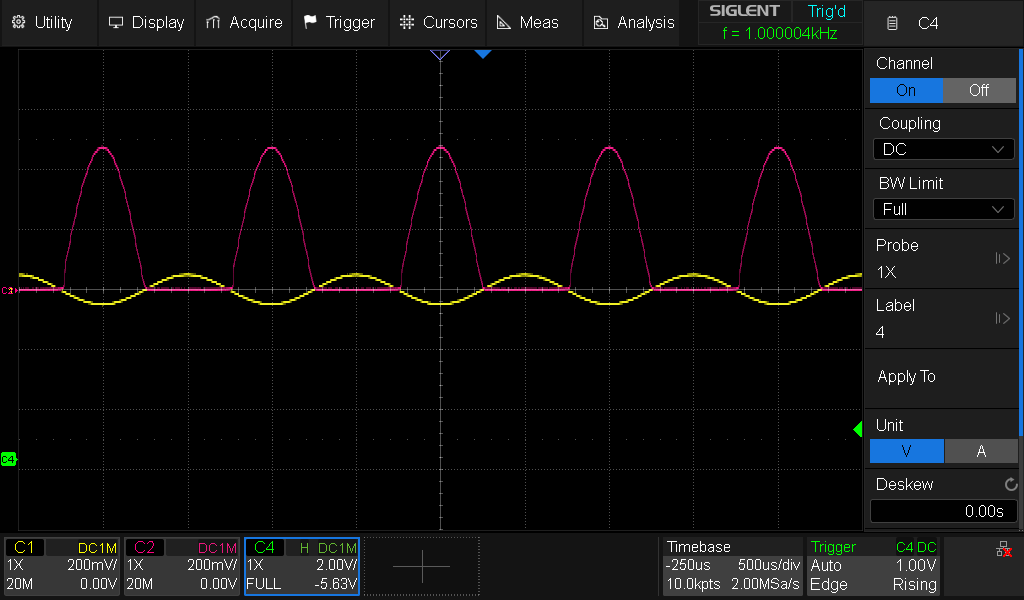

In [87]:
# For your logbook:
scope.get_screenshot()

Try adjusting the DC offset of the input signal and take some more screenshots of what happens for your logbook and describe what you see when you do this in your S&A report: 

In [88]:
gen.set_offset(1,40e-3)

You can also try negative offsets: 

In [89]:
gen.set_offset(1,-80e-3)

You can even make an "animation": 

In [90]:
# A good start

voff_max = 100e-3 ; voff_min = -100e-3
scope.write("CHAN1:SCAL 0.2")
scope.write("CHAN2:SCAL 0.2")
gen.set_offset(1,voff_max)
time.sleep(2) # for dramatic effect 

# Another option, bigger steps and tweaked ranges on scope channels
# Comment / uncomment it by selecting the code lines and using control (or mac command) + "/"

# voff_max = 600e-3 ; voff_min = -600e-3
# scope.write("CHAN1:SCAL 2")
# scope.write("CHAN2:SCAL 0.2") # note different vertical scale now on input
# gen.set_offset(1,voff_max)
# time.sleep(2) 

for voff in np.linspace(voff_max,voff_min,60):
    gen.set_offset(1,voff)
    time.sleep(0.1)

It may be illustrative to repeat this changing the vertical scale of Ch1 and Ch2 on the scope and for different ranges of the offset voltage, play around until you really understand what is going on and can answer the questions in the instructions in your R&A report. 

For comparison with the next step, you should take a screenshot of the DC coupled amplifier with a 1 V/div scale on the scope:

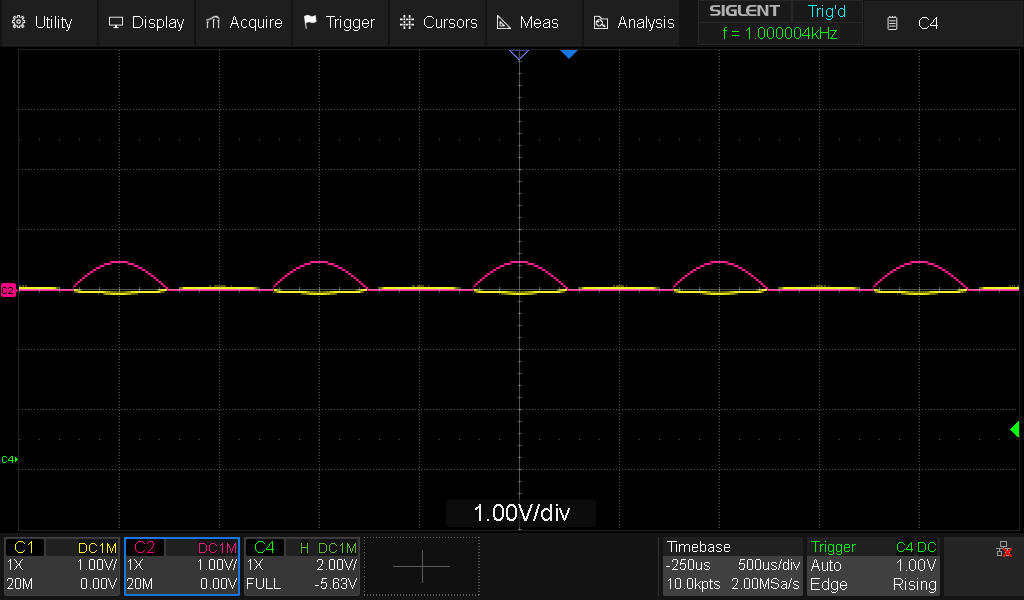

In [91]:
gen.set_offset(1,0)
scope.write("CHAN1:SCAL 1")
scope.write("CHAN2:SCAL 1")
scope.get_screenshot()

Try adjusting the DC offset of your input signal: what happens? 

In [85]:
voff = 0
gen.set_offset(1,voff)

Answer the questions in the instructions in your R&A report. 

## Step 2: An AC-coupled shunt feedback amplifier with DC offset correction

Configure the AC coupled amplifier and put the scope probe as indicated after the AC coupling capacitor. 

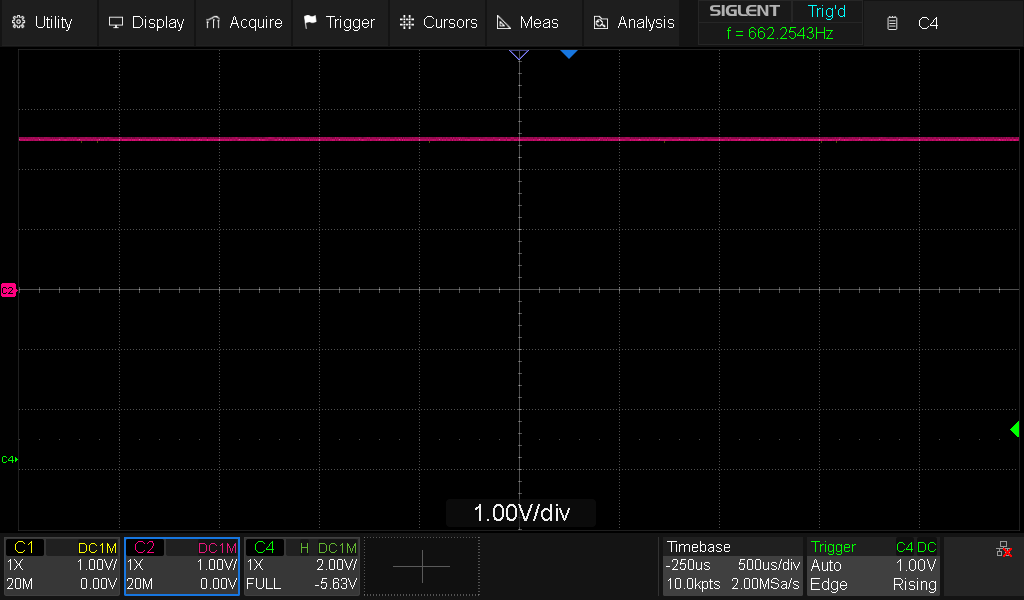

In [93]:
scope.write("CHAN1:COUP DC")
scope.write("CHAN2:COUP DC")
scope.write("CHAN1:SCAL 1")
scope.write("CHAN2:SCAL 1")
scope.get_screenshot()

## Step 3: Observing the gain for different feedback resistors

Set the scope channels to AC coupling and zoom in on input and output. 

In [130]:
scope.write("CHAN1:COUP AC")
scope.write("CHAN2:COUP AC")
gen.set_amplitude(1, 100e-3) # Start with 100 mV input with our G = 10 amplifier
scope.write("CHAN1:SCAL 0.02") # Our input is 100 mV to start
scope.write("CHAN2:SCAL 0.2") # Our output will be Gain x Vin. For larger gains, we may need to adjust this. 

For higher gains, you will likely need to reduce the amplitude of your input signal to prevent your amplifier output from saturating (clipping), and readjust the scope scales:

In [106]:
gen.set_amplitude(1, 10e-3) # 10 mV? You may need to reduce it even more. 
scope.write("CHAN1:SCAL 0.002") # Our input is now 10 mV PTP
scope.write("CHAN2:SCAL 0.02") # Our output will be Gain x Vin, adjust as needed

Get screenshots for your logbook:

In [ ]:
# For your logbook:
scope.get_screenshot()

To measure the gain, you can either:

* Use the built-in measurements buttons on the scope, and include those in your logbook, referring to them in your S&A report where you describre the gain calculation
* Use the code to download the traces, fit a cosine, and then calculate the gain. In this case, you can include screenshots of the code output and quote the gains in your S&A report

In [135]:
def f(t,a,b,c):
    return a*np.cos(2*np.pi*1e3*t+b)+c

def get_fit(t,v):
    (a,b,c), cov = curve_fit(f,t,v)
    return a,b,c

def get_amplitude(t,v):
    return np.abs(get_fit(t,v)[0]) # It could pick phase = pi and then coefficient a is negative

# In general, it is best to stop the scope trigger before grabbing the traces 
scope.write("TRIG:STOP")
t, v_in = scope.get_trace(1)
t, v_out = scope.get_trace(2)
scope.write("TRIG:RUN")

amp_in = get_amplitude(t,v_in)
amp_out = get_amplitude(t,v_out)
Gv = amp_out / amp_in # voltage gain

print("Amplitude in:  %e V" % amp_in)
print("Amplitude out: %e V" % amp_out)
print("Voltage gain: %f" % Gv)
print("Gain (dB): %f" % (20*np.log10(Gv)))

Saved to file scope_trace_2026-03-02-09.44.41.dat
Saved to file scope_trace_2026-03-02-09.44.41.dat
Amplitude in:  4.788593e-02 V
Amplitude out: 4.707025e-01 V
Voltage gain: 9.829662
Gain (dB): 19.850772


## Step 4: Bandwidth of a shunt feedback amplifier

For this, we will configure a frequency sweep ("chirp") of the input signal, capture traces of both the input singal and output signal during the frequency sweep, and then use the magic of the [Hilbert transform](https://en.wikipedia.org/wiki/Hilbert_transform) to turn this into the frequency dependent amplification 

$$ 
A(\omega) = v_{out}(\omega) / v_{in}(\omega)
$$

The Hilbert transform will return a complex variable, containing both the amplitude of the gain, and the phase that the amplifier imparts on the signal. 

This is done with code we will reuse and improve from Session 5 where you studied resonance/ 

These initial settings should give you a good measurement for the G = 10 amplifier, with the input signal displayed on the top half of the screen and the output signal on the bottom half:

In [307]:
# Set up the generators
gen.write("C1:BSWV WVTP,SINE")
gen.write("C2:BSWV WVTP,DC,OFST,5")
gen.write("C1:OUTP ON")
gen.write("C2:OUTP ON")
gen.write("C1:SYNC ON,TYPE,CH1")

# Configure the channels we will use
scope.write("CHAN1:SWIT ON")
scope.write("CHAN2:SWIT ON")
scope.write("CHAN1:COUP AC")
scope.write("CHAN2:COUP AC")
scope.write("CHAN3:SWIT OFF")
scope.write("CHAN1:SCAL 0.1")
scope.write("CHAN2:SCAL 1")
scope.write("CHAN1:OFFS 0.2")
scope.write("CHAN2:OFFS -2")
scope.write("CHAN1:VIS ON")
scope.write("CHAN2:VIS ON")
scope.write("TIM:SCAL .1e-3")
scope.write("ACQ:MDEP 1M")

# We will use Ch4 of the scope connected to the sync out of the 
# generator for triggering
scope.write("CHAN4:SWIT ON")
scope.write("CHAN4:SCAL 2")
scope.write("TRIG:EDGE:SOUR C4")
scope.write("TRIG:EDGE:LEV 1")
scope.write("CHAN4:VIS OFF")
scope.write("TRIG:RUN")

def setup_frequency_sweep(start_frequency, stop_frequency, sweep_time=1):
    # Ok, scope time base on screen goes in increments 1, 2, 5, 10...    
    mantissa = float(("%e" %  sweep_time).split("e")[0])
    exponent = float(("%e" %  sweep_time).split("e")[1])
    allowed = np.array([1, 2, 5, 10])
    idx = np.abs(allowed - mantissa).argmin()
    mantissa = allowed[idx]
    sweep_time = float("%fe%d" % (mantissa, exponent))
    print("Picking sweep time %e based on nearest allowed division of scope display" % sweep_time)
    
    # Configurting sweep, page 26 of manual of SDG1000 
    gen.write("C1:SWWV STATE,ON")
    gen.write("C1:SWWV TIME,%f" % sweep_time)
    gen.write("C1:SWWV STOP,%f" % stop_frequency)
    gen.write("C1:SWWV START,%f" % start_frequency)
    
    # This will automatically set up the time base of the scope in a good way :)
    scope.write("TIM:SCAL %f" % (sweep_time/10)) # The display has 10 "divisions"...
    scope.write("TIM:DEL %f" % (sweep_time/2)) # Set horizontal position to show full sweep on screen

# With top / bottom display, we need to change the offset
# if we change the scale. This function will do this automatically for you. 
def set_scope_scale(channel_number, scale):
    scope.write("CHAN%d:SCAL %e" % (channel_number,scale))
    if channel_number == 1:
        scope.write("CHAN1:OFFS %e" % (scale*2))
    else:
        scope.write("CHAN2:OFFS %e" % (-scale*2))

f1 = 10e3  # You can change f1 and f2 to achieve different frequency ranges
f2 = 1e6
setup_frequency_sweep(f1, f2, sweep_time = 1)

Picking sweep time 1.000000e+00 based on nearest allowed division of scope display


As you change the gain of the amplfier, and the amplitude of the input signal, you may want to change the scale of scope channels. To keep the display aligned nicely, you can use this function:

In [308]:
set_scope_scale(1,0.05)
set_scope_scale(2,0.4)

On the screen of the scope, we can in principle now already visually see the amplitude reponse. We may need to adjust the vertical scales of the scope, and also you may need to reduce or increase the amplitude of the generator Ch1 in to prevent your amplifier from clipping / saturating. 

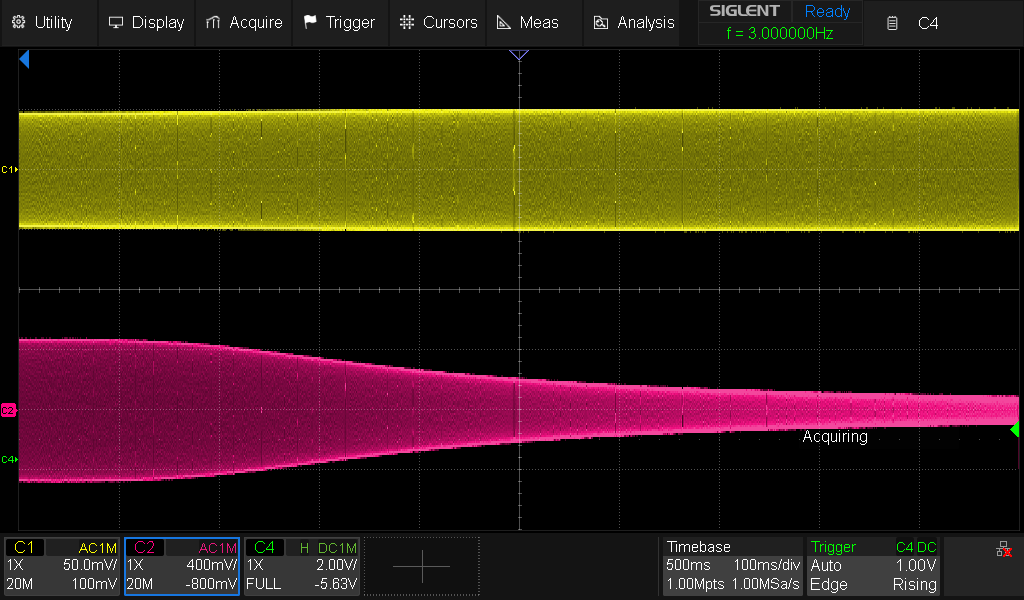

In [309]:
scope.get_screenshot()

Once you think it looks good, you can grab the traces and calculate the response function using this code that employs Hilbert transform magic:

In [329]:
def make_response_function(v_out, v_in, f_start, f_stop):
    # we will average to reduce the noise: we need a lot of points in time to measure 1 MHz but do not need 1 million 
    # points in our calculated frequency reponse function. 
    navg = 1000 
    N = len(v_in) // navg
    f = np.linspace(f_start, f_stop, len(v_in)//navg)
    v_out_t = hilbert(v_out)
    v_in_t = hilbert(v_in)
    R = v_out_t / v_in_t
    R = np.average(np.reshape(R[0:N*navg],(N,navg)),axis=1)
    n_crop = N//500 # crop out some frequencies at the start and end due to FFT periodic boundary conditions
    print("Initial frequency range %.3f kHz to %.3f kHz" % (f[0]/1e3, f[-1]/1e3))
    print("Cropping from frequency %.3f kHz to %.3f kHz due to FFT" % (f[n_crop]/1e3, f[-n_crop]/1e3))
    return f[n_crop:-n_crop], np.abs(R[n_crop:-n_crop])

Do a frequency sweep and calculate the response function!

Note that there will be a small blip in the middle of your trace due to issues with the Hilbert transform noise: this can be eliminated by extending the memory depth to 10M points but then downloading traces takes a long time. Also, the code that calculates the reponse function also crops 

In [341]:
f1 = 1e3  # You can change f1 and f2 to achieve different frequency ranges
f2 = 1e6
setup_frequency_sweep(f1, f2, sweep_time = 1)
time.sleep(5) # wait for the scope to trigger and do an acquisition

print("Be patient: with 1M points, it will take about 5 seconds to download each trace")
scope.write("TRIG:STOP")
t,v_in = scope.get_trace(1, npoints='all')
t,v_out = scope.get_trace(2, npoints='all')
scope.write("TRIG:RUN")

f, A = make_response_function(v_out, v_in, f1, f2)

Picking sweep time 1.000000e+00 based on nearest allowed division of scope display
Be patient: with 1M points, it will take about 5 seconds to download each trace
Saved to file scope_trace_2026-03-02-13.48.40.dat
Saved to file scope_trace_2026-03-02-13.48.43.dat
Initial frequency range 1.000 kHz to 1000.000 kHz
Cropping from frequency 3.000 kHz to 999.000 kHz due to FFT


And plot it, both in voltage gain and in dB:

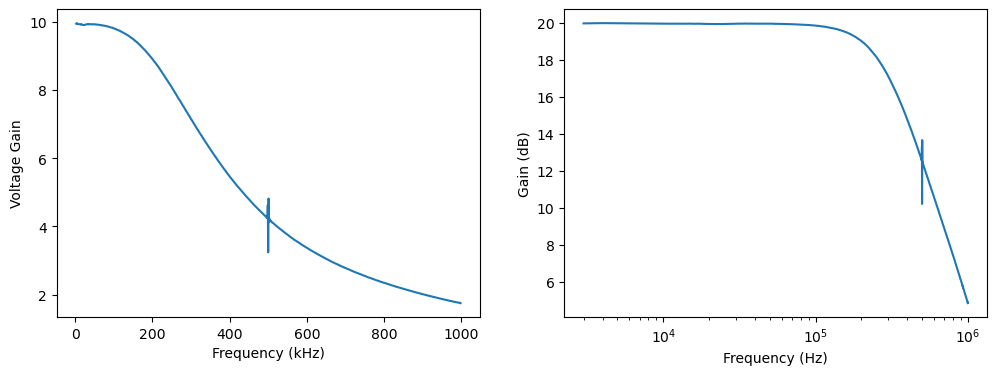

In [342]:
dB = 20*np.log10(A)
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(f/1e3, A)
plt.xlabel("Frequency (kHz)")
plt.ylabel("Voltage Gain")
plt.subplot(122)
plt.plot(f, 20*np.log10(A))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain (dB)") # In dB, there is no difference between voltage gain and power gain...
plt.xscale("log")
plt.show()

# Level 2 work

Add your own code and code cells below for your level 2 work. 

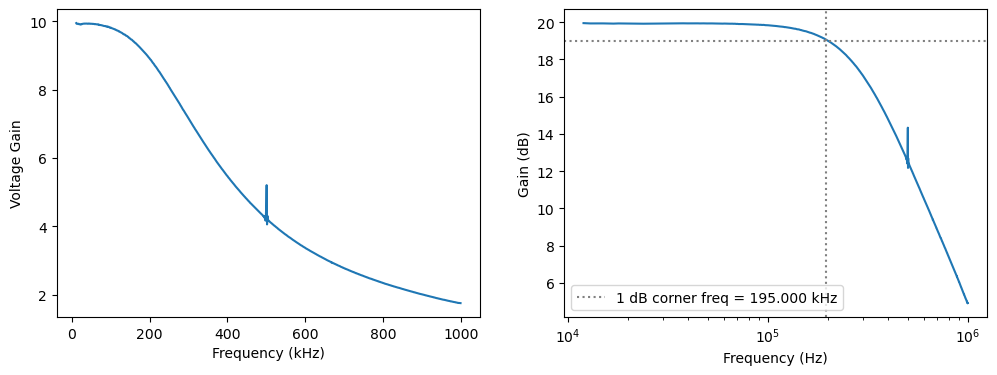

In [334]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(f/1e3, A)
plt.xlabel("Frequency (kHz)")
plt.ylabel("Voltage Gain")
plt.subplot(122)
plt.plot(f, 20*np.log10(A))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain (dB)") # In dB, there is no difference between voltage gain and power gain...
plt.xscale("log")

# Level 2: Can use these to measure the 1 dB corner frequency by manually lininig them up to cross

low_freq_gain = 20
plt.axhline(low_freq_gain - 1, ls=':', c='gray')
f_corner = 1.95e5
plt.axvline(f_corner, ls=':', c='gray', label="1 dB corner freq = %.3f kHz" % (f_corner/1e3))
plt.legend()
plt.show()